# 라이브러리 및 데이터 불러오기

In [122]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [123]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

In [124]:
df_cine = pd.read_csv("C:\\workspace\\sprint_mission16\\data\\cine21_movies.csv")
df_cine.head()

,title,rank,score,daily_aud,total_aud,open_date,link,등급,시간,장르,국가,감독,0,review
0,스파이더맨: 브랜드 뉴 데이,1,7.33,2124592,5910553,2026-07-29,/movie/info/?movie_id=63091,12세이상,144.0,"판타지, 어드벤처, 액션",미국,데스틴 크리튼,7.33,"['하이틴의 겉옷을 벗고 근본으로 돌아간 성장', '큰 힘과 큰 책임이 서로를 따르..."
1,오디세이,2,7.55,1871575,1872877,2026-08-05,/movie/info/?movie_id=62585,15세이상,172.0,"액션, 모험, 드라마",미국,크리스토퍼 놀란,7.55,"['그리스신화는 놀런을 만나길 오랫동안 기다려왔구나', '늘 해오던 걸 가장 잘 할..."
2,사랑의 하츄핑: 고래보석의 전설,3,7.00,407067,433565,2026-08-05,/movie/info/?movie_id=63075,전체,105.0,애니메이션,한국,김수훈,7.00,"['시네마 키드는 어떻게 육성되는가, 이 영화를 보고 자랄 어린이들에게']"
3,호프,4,6.83,219132,4393518,2026-07-15,/movie/info/?movie_id=62480,15세이상,156.0,"액션, 스릴러, SF",한국,나홍진,6.83,"['후진 없는 희망의 트럭', '쾌감의 짝인 공허까지도 납득시킨다', '끌렸다, 즐..."
4,미니언즈 & 몬스터즈,5,6.50,36881,763404,2026-07-15,/movie/info/?movie_id=63032,전체,89.0,애니메이션,미국,피에르 코팽,6.50,"['직업 체험도 좋지만 역시 본업 할 때가 최고', '천사들의 도시로 간 헨리 제임..."


### df_cine
- 26년 8월 10일 시점의 씨네21 박스오피스 10개 영화 데이터 프레임
- "명탐정 코난: 하이웨이의 타천사"의 경우 사전 상영으로 인한 집계가 진행된 것으로 확인되며, 정식 개봉일은 8월 12일로 데이터 분석시 세부분석을 진행하기에는 제한사항이 많으므로 제외.

In [125]:
df_kobis = pd.read_csv("C:\\workspace\\sprint_mission16\\data\\kobis_movies.csv")
df_kobis.head()


,rnum,rank,rankInten,rankOldAndNew,movieCd,movieNm,openDt,salesAmt,salesShare,salesInten,salesChange,salesAcc,audiCnt,audiInten,audiChange,audiAcc,scrnCnt,showCnt,targetDt
0,1,1,0,OLD,20233219,호프,2026-07-15,1057559480,59.5,-1943517630,-64.8,38318463580,103403,-182467,-63.8,3519073,2096,7272,20260727
1,2,2,0,OLD,20261784,미니언즈 & 몬스터즈,2026-07-15,202780900,11.4,-275022600,-57.6,5949070580,21401,-27044,-55.8,584363,774,1856,20260727
2,3,3,0,OLD,20259946,모아나,2026-07-08,145849290,8.2,-200917990,-57.9,9905629670,15049,-19753,-56.8,924284,704,1403,20260727
3,4,4,0,OLD,20259781,토이 스토리 5,2026-06-17,112255100,6.3,-116820500,-51.0,29335606860,11521,-10966,-48.8,2848640,522,854,20260727
4,5,5,1,OLD,20242402,눈동자,2026-06-24,68698000,3.9,-69954370,-50.5,15664161540,6698,-6376,-48.8,1518312,545,885,20260727


In [126]:
df_kobis['targetDt'].unique()

array([20260727, 20260728, 20260729, 20260730, 20260731, 20260801,
       20260802, 20260803, 20260804, 20260805, 20260806, 20260807,
       20260808, 20260809, 20260810])

### df_kobis
- kobis 사이트 API 활용 7월 27일~8월 10일까지의 일자별 Top 10 영화 스크래핑 데이터

# 전처리

## 중복값

In [127]:
df_cine.duplicated().sum()

np.int64(0)

In [128]:
df_kobis.duplicated().sum()

np.int64(0)

## 결측값

In [129]:
print(df_cine.isna().sum().sum())
print(df_kobis.isna().sum().sum())

9
0


In [130]:
df_cine.isna().sum()

title        0
rank         0
score        1
daily_aud    0
total_aud    0
open_date    1
link         0
등급           1
시간           1
장르           1
국가           1
감독           1
0            1
review       1
dtype: int64

In [131]:
df_cine

,title,rank,score,daily_aud,total_aud,open_date,link,등급,시간,장르,국가,감독,0,review
0,스파이더맨: 브랜드 뉴 데이,1,7.33,2124592,5910553,2026-07-29,/movie/info/?movie_id=63091,12세이상,144.0,"판타지, 어드벤처, 액션",미국,데스틴 크리튼,7.33,"['하이틴의 겉옷을 벗고 근본으로 돌아간 성장', '큰 힘과 큰 책임이 서로를 따르..."
1,오디세이,2,7.55,1871575,1872877,2026-08-05,/movie/info/?movie_id=62585,15세이상,172.0,"액션, 모험, 드라마",미국,크리스토퍼 놀란,7.55,"['그리스신화는 놀런을 만나길 오랫동안 기다려왔구나', '늘 해오던 걸 가장 잘 할..."
2,사랑의 하츄핑: 고래보석의 전설,3,7.00,407067,433565,2026-08-05,/movie/info/?movie_id=63075,전체,105.0,애니메이션,한국,김수훈,7.00,"['시네마 키드는 어떻게 육성되는가, 이 영화를 보고 자랄 어린이들에게']"
3,호프,4,6.83,219132,4393518,2026-07-15,/movie/info/?movie_id=62480,15세이상,156.0,"액션, 스릴러, SF",한국,나홍진,6.83,"['후진 없는 희망의 트럭', '쾌감의 짝인 공허까지도 납득시킨다', '끌렸다, 즐..."
4,미니언즈 & 몬스터즈,5,6.50,36881,763404,2026-07-15,/movie/info/?movie_id=63032,전체,89.0,애니메이션,미국,피에르 코팽,6.50,"['직업 체험도 좋지만 역시 본업 할 때가 최고', '천사들의 도시로 간 헨리 제임..."
5,다윗,6,5.00,22913,289372,2026-07-10,/movie/info/?movie_id=63108,전체,109.0,애니메이션,미국,필 커닝햄 브렌트 도스,5.00,['검 대신 악기를 드는 성경 뮤지컬']
6,어떻게 해야 했을까?,7,6.50,22558,49713,2026-07-29,/movie/info/?movie_id=63282,12세이상,101.0,다큐멘터리,일본,후지노 토모아키,6.50,"['‘무엇을 찍었나’로 시작되는 고통. ‘어디서 끊을까’로 확장되는 고뇌', '미해..."
7,토이 스토리 5,8,6.83,19707,2938990,2026-06-17,/movie/info/?movie_id=62799,전체,101.0,애니메이션,미국,앤드류 스탠튼 맥케나 해리스,6.83,"['그 무한한 애정을 어찌 사랑하지 않을 수 있을까', '뭉클하고 눈물겨우나 이젠 ..."
8,모아나,9,5.67,13996,1020487,2026-07-08,/movie/info/?movie_id=62818,전체,115.0,"어드벤처, 액션",미국,토마스 케일,5.67,"['붕어빵이 맛보다 비주얼을 뽐내면', '디즈니 실사영화 논란을 잠재울 충실한 구현..."
9,명탐정 코난: 하이웨이의 타천사,10,NaN,8828,8828,NaN,javascript:;,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [132]:
print(df_cine["review"].dtype)
print(type(df_cine.loc[0, "review"]))

str
<class 'str'>


In [133]:
df_cine['score'] = df_cine['score'].fillna(0)
df_cine['open_date'] = df_cine['open_date'].fillna("2026-08-12")
df_cine['link'] = df_cine['link'].replace("javascript:;", "/movie/info/?movie_id=63245")
df_cine['등급'] = df_cine['등급'].fillna("12세이상")
df_cine['시간'] = df_cine['시간'].fillna(109)
df_cine['장르'] = df_cine['장르'].fillna("애니메이션")
df_cine['국가'] = df_cine['국가'].fillna("일본")
df_cine['감독'] = df_cine['감독'].fillna("하스이 타카히로")
df_cine["0"] = df_cine["0"].fillna(6.00)
df_cine["review"] = df_cine["review"].astype(object)
idx = df_cine[df_cine["review"].isna()].index[0]

df_cine.at[idx, "review"] = [
    "스피드에 깔린 미스터리",
    "나도 따라 덜컹거리는 곡선의 박진감. 롤러코스터를 탄 것 같지 않아, 소년?",
    "추리를 접고 직진하여 원점 회귀"
]

In [134]:
df_cine

,title,rank,score,daily_aud,total_aud,open_date,link,등급,시간,장르,국가,감독,0,review
0,스파이더맨: 브랜드 뉴 데이,1,7.33,2124592,5910553,2026-07-29,/movie/info/?movie_id=63091,12세이상,144.0,"판타지, 어드벤처, 액션",미국,데스틴 크리튼,7.33,"['하이틴의 겉옷을 벗고 근본으로 돌아간 성장', '큰 힘과 큰 책임이 서로를 따르..."
1,오디세이,2,7.55,1871575,1872877,2026-08-05,/movie/info/?movie_id=62585,15세이상,172.0,"액션, 모험, 드라마",미국,크리스토퍼 놀란,7.55,"['그리스신화는 놀런을 만나길 오랫동안 기다려왔구나', '늘 해오던 걸 가장 잘 할..."
2,사랑의 하츄핑: 고래보석의 전설,3,7.00,407067,433565,2026-08-05,/movie/info/?movie_id=63075,전체,105.0,애니메이션,한국,김수훈,7.00,"['시네마 키드는 어떻게 육성되는가, 이 영화를 보고 자랄 어린이들에게']"
3,호프,4,6.83,219132,4393518,2026-07-15,/movie/info/?movie_id=62480,15세이상,156.0,"액션, 스릴러, SF",한국,나홍진,6.83,"['후진 없는 희망의 트럭', '쾌감의 짝인 공허까지도 납득시킨다', '끌렸다, 즐..."
4,미니언즈 & 몬스터즈,5,6.50,36881,763404,2026-07-15,/movie/info/?movie_id=63032,전체,89.0,애니메이션,미국,피에르 코팽,6.50,"['직업 체험도 좋지만 역시 본업 할 때가 최고', '천사들의 도시로 간 헨리 제임..."
5,다윗,6,5.00,22913,289372,2026-07-10,/movie/info/?movie_id=63108,전체,109.0,애니메이션,미국,필 커닝햄 브렌트 도스,5.00,['검 대신 악기를 드는 성경 뮤지컬']
6,어떻게 해야 했을까?,7,6.50,22558,49713,2026-07-29,/movie/info/?movie_id=63282,12세이상,101.0,다큐멘터리,일본,후지노 토모아키,6.50,"['‘무엇을 찍었나’로 시작되는 고통. ‘어디서 끊을까’로 확장되는 고뇌', '미해..."
7,토이 스토리 5,8,6.83,19707,2938990,2026-06-17,/movie/info/?movie_id=62799,전체,101.0,애니메이션,미국,앤드류 스탠튼 맥케나 해리스,6.83,"['그 무한한 애정을 어찌 사랑하지 않을 수 있을까', '뭉클하고 눈물겨우나 이젠 ..."
8,모아나,9,5.67,13996,1020487,2026-07-08,/movie/info/?movie_id=62818,전체,115.0,"어드벤처, 액션",미국,토마스 케일,5.67,"['붕어빵이 맛보다 비주얼을 뽐내면', '디즈니 실사영화 논란을 잠재울 충실한 구현..."
9,명탐정 코난: 하이웨이의 타천사,10,0.00,8828,8828,2026-08-12,/movie/info/?movie_id=63245,12세이상,109.0,애니메이션,일본,하스이 타카히로,6.00,"[스피드에 깔린 미스터리, 나도 따라 덜컹거리는 곡선의 박진감. 롤러코스터를 탄 것..."


In [135]:
df_cine["review"] = df_cine["review"].astype(str)

In [136]:
df_cine

,title,rank,score,daily_aud,total_aud,open_date,link,등급,시간,장르,국가,감독,0,review
0,스파이더맨: 브랜드 뉴 데이,1,7.33,2124592,5910553,2026-07-29,/movie/info/?movie_id=63091,12세이상,144.0,"판타지, 어드벤처, 액션",미국,데스틴 크리튼,7.33,"['하이틴의 겉옷을 벗고 근본으로 돌아간 성장', '큰 힘과 큰 책임이 서로를 따르..."
1,오디세이,2,7.55,1871575,1872877,2026-08-05,/movie/info/?movie_id=62585,15세이상,172.0,"액션, 모험, 드라마",미국,크리스토퍼 놀란,7.55,"['그리스신화는 놀런을 만나길 오랫동안 기다려왔구나', '늘 해오던 걸 가장 잘 할..."
2,사랑의 하츄핑: 고래보석의 전설,3,7.00,407067,433565,2026-08-05,/movie/info/?movie_id=63075,전체,105.0,애니메이션,한국,김수훈,7.00,"['시네마 키드는 어떻게 육성되는가, 이 영화를 보고 자랄 어린이들에게']"
3,호프,4,6.83,219132,4393518,2026-07-15,/movie/info/?movie_id=62480,15세이상,156.0,"액션, 스릴러, SF",한국,나홍진,6.83,"['후진 없는 희망의 트럭', '쾌감의 짝인 공허까지도 납득시킨다', '끌렸다, 즐..."
4,미니언즈 & 몬스터즈,5,6.50,36881,763404,2026-07-15,/movie/info/?movie_id=63032,전체,89.0,애니메이션,미국,피에르 코팽,6.50,"['직업 체험도 좋지만 역시 본업 할 때가 최고', '천사들의 도시로 간 헨리 제임..."
5,다윗,6,5.00,22913,289372,2026-07-10,/movie/info/?movie_id=63108,전체,109.0,애니메이션,미국,필 커닝햄 브렌트 도스,5.00,['검 대신 악기를 드는 성경 뮤지컬']
6,어떻게 해야 했을까?,7,6.50,22558,49713,2026-07-29,/movie/info/?movie_id=63282,12세이상,101.0,다큐멘터리,일본,후지노 토모아키,6.50,"['‘무엇을 찍었나’로 시작되는 고통. ‘어디서 끊을까’로 확장되는 고뇌', '미해..."
7,토이 스토리 5,8,6.83,19707,2938990,2026-06-17,/movie/info/?movie_id=62799,전체,101.0,애니메이션,미국,앤드류 스탠튼 맥케나 해리스,6.83,"['그 무한한 애정을 어찌 사랑하지 않을 수 있을까', '뭉클하고 눈물겨우나 이젠 ..."
8,모아나,9,5.67,13996,1020487,2026-07-08,/movie/info/?movie_id=62818,전체,115.0,"어드벤처, 액션",미국,토마스 케일,5.67,"['붕어빵이 맛보다 비주얼을 뽐내면', '디즈니 실사영화 논란을 잠재울 충실한 구현..."
9,명탐정 코난: 하이웨이의 타천사,10,0.00,8828,8828,2026-08-12,/movie/info/?movie_id=63245,12세이상,109.0,애니메이션,일본,하스이 타카히로,6.00,"['스피드에 깔린 미스터리', '나도 따라 덜컹거리는 곡선의 박진감. 롤러코스터를 ..."


In [137]:
df_cine.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      10 non-null     str    
 1   rank       10 non-null     int64  
 2   score      10 non-null     float64
 3   daily_aud  10 non-null     int64  
 4   total_aud  10 non-null     int64  
 5   open_date  10 non-null     str    
 6   link       10 non-null     str    
 7   등급         10 non-null     str    
 8   시간         10 non-null     float64
 9   장르         10 non-null     str    
 10  국가         10 non-null     str    
 11  감독         10 non-null     str    
 12  0          10 non-null     float64
 13  review     10 non-null     str    
dtypes: float64(3), int64(3), str(8)
memory usage: 1.2 KB


## 데이터 타입 변경

In [138]:
df_kobis

,rnum,rank,rankInten,rankOldAndNew,movieCd,movieNm,openDt,salesAmt,salesShare,salesInten,salesChange,salesAcc,audiCnt,audiInten,audiChange,audiAcc,scrnCnt,showCnt,targetDt
0,1,1,0,OLD,20233219,호프,2026-07-15,1057559480,59.5,-1943517630,-64.8,38318463580,103403,-182467,-63.8,3519073,2096,7272,20260727
1,2,2,0,OLD,20261784,미니언즈 & 몬스터즈,2026-07-15,202780900,11.4,-275022600,-57.6,5949070580,21401,-27044,-55.8,584363,774,1856,20260727
2,3,3,0,OLD,20259946,모아나,2026-07-08,145849290,8.2,-200917990,-57.9,9905629670,15049,-19753,-56.8,924284,704,1403,20260727
3,4,4,0,OLD,20259781,토이 스토리 5,2026-06-17,112255100,6.3,-116820500,-51.0,29335606860,11521,-10966,-48.8,2848640,522,854,20260727
4,5,5,1,OLD,20242402,눈동자,2026-06-24,68698000,3.9,-69954370,-50.5,15664161540,6698,-6376,-48.8,1518312,545,885,20260727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,6,6,0,OLD,20261784,미니언즈 & 몬스터즈,2026-07-15,19237500,0.4,-25821180,-57.3,7612121820,2193,-2821,-56.3,765485,208,217,20260810
146,7,7,3,OLD,20259781,토이 스토리 5,2026-06-17,10804150,0.2,-7973700,-42.5,30219382390,1112,-795,-41.7,2940488,109,112,20260810
147,8,8,-3,OLD,20262902,다윗,2026-07-10,9168150,0.2,-69105900,-88.3,2816467330,958,-7384,-88.5,290308,65,69,20260810
148,9,9,3,OLD,20259946,모아나,2026-07-08,7290500,0.1,748300,11.4,10828554930,826,149,22.0,1021761,67,70,20260810


In [139]:
df_kobis.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rnum           150 non-null    int64  
 1   rank           150 non-null    int64  
 2   rankInten      150 non-null    int64  
 3   rankOldAndNew  150 non-null    str    
 4   movieCd        150 non-null    int64  
 5   movieNm        150 non-null    str    
 6   openDt         150 non-null    str    
 7   salesAmt       150 non-null    int64  
 8   salesShare     150 non-null    float64
 9   salesInten     150 non-null    int64  
 10  salesChange    150 non-null    float64
 11  salesAcc       150 non-null    int64  
 12  audiCnt        150 non-null    int64  
 13  audiInten      150 non-null    int64  
 14  audiChange     150 non-null    float64
 15  audiAcc        150 non-null    int64  
 16  scrnCnt        150 non-null    int64  
 17  showCnt        150 non-null    int64  
 18  targetDt       150 no

In [140]:
df_kobis["targetDt"] = pd.to_datetime(
    df_kobis["targetDt"].astype(str),
    format="%Y%m%d"
)

In [141]:
df_kobis["openDt"] = pd.to_datetime(df_kobis["openDt"])
df_kobis.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   rnum           150 non-null    int64         
 1   rank           150 non-null    int64         
 2   rankInten      150 non-null    int64         
 3   rankOldAndNew  150 non-null    str           
 4   movieCd        150 non-null    int64         
 5   movieNm        150 non-null    str           
 6   openDt         150 non-null    datetime64[us]
 7   salesAmt       150 non-null    int64         
 8   salesShare     150 non-null    float64       
 9   salesInten     150 non-null    int64         
 10  salesChange    150 non-null    float64       
 11  salesAcc       150 non-null    int64         
 12  audiCnt        150 non-null    int64         
 13  audiInten      150 non-null    int64         
 14  audiChange     150 non-null    float64       
 15  audiAcc        150 non-null    int

In [142]:
df_kobis.columns

Index(['rnum', 'rank', 'rankInten', 'rankOldAndNew', 'movieCd', 'movieNm',
       'openDt', 'salesAmt', 'salesShare', 'salesInten', 'salesChange',
       'salesAcc', 'audiCnt', 'audiInten', 'audiChange', 'audiAcc', 'scrnCnt',
       'showCnt', 'targetDt'],
      dtype='str')

In [143]:
col_rename = {'rnum':"순번", 'rank':"순위", 'rankInten':'전일대비_순위증감', 'rankOldAndNew':'신규진입여부', 'movieNm':'영화제목',
       'openDt':'개봉일', 'salesAmt':'매출액', 'salesShare':'당일매출비율', 'salesInten':'전일대비_매출증감', 'salesChange':'전일대비_매출액_증감비율',
       'salesAcc':'누적매출액', 'audiCnt':'당일관객수', 'audiInten':'전일대비_관객증감', 'audiChange':'전일대비_관객증감비율', 'audiAcc':'누적관객수', 'scrnCnt':'당일스크린수',
       }

df_kobis = df_kobis.rename(columns=col_rename)
df_kobis.head()

,순번,순위,전일대비_순위증감,신규진입여부,movieCd,영화제목,개봉일,매출액,당일매출비율,전일대비_매출증감,전일대비_매출액_증감비율,누적매출액,당일관객수,전일대비_관객증감,전일대비_관객증감비율,누적관객수,당일스크린수,showCnt,targetDt
0,1,1,0,OLD,20233219,호프,2026-07-15,1057559480,59.5,-1943517630,-64.8,38318463580,103403,-182467,-63.8,3519073,2096,7272,2026-07-27
1,2,2,0,OLD,20261784,미니언즈 & 몬스터즈,2026-07-15,202780900,11.4,-275022600,-57.6,5949070580,21401,-27044,-55.8,584363,774,1856,2026-07-27
2,3,3,0,OLD,20259946,모아나,2026-07-08,145849290,8.2,-200917990,-57.9,9905629670,15049,-19753,-56.8,924284,704,1403,2026-07-27
3,4,4,0,OLD,20259781,토이 스토리 5,2026-06-17,112255100,6.3,-116820500,-51.0,29335606860,11521,-10966,-48.8,2848640,522,854,2026-07-27
4,5,5,1,OLD,20242402,눈동자,2026-06-24,68698000,3.9,-69954370,-50.5,15664161540,6698,-6376,-48.8,1518312,545,885,2026-07-27


# 기술통계 확인

In [144]:
df_cine.describe()

,rank,score,daily_aud,total_aud,시간,0
count,10.00000,10.000000,1.000000e+01,1.000000e+01,10.000000,10.000000
mean,5.50000,5.921000,4.747249e+05,1.768131e+06,120.100000,6.521000
std,3.02765,2.213486,8.151227e+05,2.028096e+06,27.387954,0.777724
min,1.00000,0.000000,8.828000e+03,8.828000e+03,89.000000,5.000000
25%,3.25000,5.877500,2.041975e+04,3.254202e+05,102.000000,6.125000
50%,5.50000,6.665000,2.989700e+04,8.919455e+05,109.000000,6.665000
75%,7.75000,6.957500,3.600832e+05,2.672462e+06,136.750000,6.957500
max,10.00000,7.550000,2.124592e+06,5.910553e+06,172.000000,7.550000


In [145]:
df_kobis.describe()

,순번,순위,전일대비_순위증감,movieCd,개봉일,매출액,당일매출비율,전일대비_매출증감,전일대비_매출액_증감비율,누적매출액,당일관객수,전일대비_관객증감,전일대비_관객증감비율,누적관객수,당일스크린수,showCnt,targetDt
count,150.000000,150.000000,150.000000,1.500000e+02,150,1.500000e+02,150.000000,1.500000e+02,150.000000,1.500000e+02,150.00000,150.000000,150.000000,1.500000e+02,150.000000,150.000000,150
mean,5.500000,5.500000,0.133333,2.025708e+07,2026-07-14 23:31:12,7.138418e+08,9.868667,5.979727e+06,467.902667,1.621772e+10,68515.60000,477.560000,604.474667,1.554338e+06,544.346667,1456.366667,2026-08-03 00:00:00
min,1.000000,1.000000,-4.000000,2.023322e+07,2026-02-04 00:00:00,2.896500e+06,0.100000,-4.605884e+09,-88.300000,6.714000e+06,290.00000,-424555.000000,-88.500000,7.460000e+02,2.000000,2.000000,2026-07-27 00:00:00
25%,3.000000,3.000000,0.000000,2.025548e+07,2026-07-08 00:00:00,2.541655e+07,0.400000,-3.452693e+07,-30.600000,6.367061e+08,2496.50000,-3153.750000,-28.500000,6.417750e+04,83.500000,116.500000,2026-07-30 00:00:00
50%,5.500000,5.500000,0.000000,2.026178e+07,2026-07-15 00:00:00,6.148775e+07,1.000000,-1.317000e+06,-2.000000,7.481888e+09,6248.00000,-139.000000,-2.500000,7.509385e+05,272.000000,299.000000,2026-08-03 00:00:00
75%,8.000000,8.000000,0.000000,2.026290e+07,2026-07-29 00:00:00,2.510512e+08,6.025000,7.613725e+06,23.625000,2.971058e+10,26157.50000,856.500000,20.475000,2.888121e+06,722.000000,1343.250000,2026-08-07 00:00:00
max,10.000000,10.000000,8.000000,2.026525e+07,2026-08-13 00:00:00,9.697313e+09,83.200000,6.898417e+09,39226.800000,1.632156e+11,901580.00000,689728.000000,55002.200000,1.691628e+07,2409.000000,10152.000000,2026-08-10 00:00:00
std,2.881904,2.881904,1.608145,9.807642e+03,NaN,1.673799e+09,20.420568,9.603732e+08,3796.939700,2.131185e+10,157878.06402,92875.017341,5038.700546,2.083003e+06,634.840497,2407.298897,NaN


In [146]:
df_kobis.isna().sum()

순번               0
순위               0
전일대비_순위증감        0
신규진입여부           0
movieCd          0
영화제목             0
개봉일              0
매출액              0
당일매출비율           0
전일대비_매출증감        0
전일대비_매출액_증감비율    0
누적매출액            0
당일관객수            0
전일대비_관객증감        0
전일대비_관객증감비율      0
누적관객수            0
당일스크린수           0
showCnt          0
targetDt         0
dtype: int64

In [147]:
df_cine.to_csv(
    "../data/df_cine.csv",
    index=False,
    encoding="utf-8-sig"
)

df_kobis.to_csv(
    "../data/df_kobis.csv",
    index=False,
    encoding="utf-8-sig"
)

In [148]:
df_cine

,title,rank,score,daily_aud,total_aud,open_date,link,등급,시간,장르,국가,감독,0,review
0,스파이더맨: 브랜드 뉴 데이,1,7.33,2124592,5910553,2026-07-29,/movie/info/?movie_id=63091,12세이상,144.0,"판타지, 어드벤처, 액션",미국,데스틴 크리튼,7.33,"['하이틴의 겉옷을 벗고 근본으로 돌아간 성장', '큰 힘과 큰 책임이 서로를 따르..."
1,오디세이,2,7.55,1871575,1872877,2026-08-05,/movie/info/?movie_id=62585,15세이상,172.0,"액션, 모험, 드라마",미국,크리스토퍼 놀란,7.55,"['그리스신화는 놀런을 만나길 오랫동안 기다려왔구나', '늘 해오던 걸 가장 잘 할..."
2,사랑의 하츄핑: 고래보석의 전설,3,7.00,407067,433565,2026-08-05,/movie/info/?movie_id=63075,전체,105.0,애니메이션,한국,김수훈,7.00,"['시네마 키드는 어떻게 육성되는가, 이 영화를 보고 자랄 어린이들에게']"
3,호프,4,6.83,219132,4393518,2026-07-15,/movie/info/?movie_id=62480,15세이상,156.0,"액션, 스릴러, SF",한국,나홍진,6.83,"['후진 없는 희망의 트럭', '쾌감의 짝인 공허까지도 납득시킨다', '끌렸다, 즐..."
4,미니언즈 & 몬스터즈,5,6.50,36881,763404,2026-07-15,/movie/info/?movie_id=63032,전체,89.0,애니메이션,미국,피에르 코팽,6.50,"['직업 체험도 좋지만 역시 본업 할 때가 최고', '천사들의 도시로 간 헨리 제임..."
5,다윗,6,5.00,22913,289372,2026-07-10,/movie/info/?movie_id=63108,전체,109.0,애니메이션,미국,필 커닝햄 브렌트 도스,5.00,['검 대신 악기를 드는 성경 뮤지컬']
6,어떻게 해야 했을까?,7,6.50,22558,49713,2026-07-29,/movie/info/?movie_id=63282,12세이상,101.0,다큐멘터리,일본,후지노 토모아키,6.50,"['‘무엇을 찍었나’로 시작되는 고통. ‘어디서 끊을까’로 확장되는 고뇌', '미해..."
7,토이 스토리 5,8,6.83,19707,2938990,2026-06-17,/movie/info/?movie_id=62799,전체,101.0,애니메이션,미국,앤드류 스탠튼 맥케나 해리스,6.83,"['그 무한한 애정을 어찌 사랑하지 않을 수 있을까', '뭉클하고 눈물겨우나 이젠 ..."
8,모아나,9,5.67,13996,1020487,2026-07-08,/movie/info/?movie_id=62818,전체,115.0,"어드벤처, 액션",미국,토마스 케일,5.67,"['붕어빵이 맛보다 비주얼을 뽐내면', '디즈니 실사영화 논란을 잠재울 충실한 구현..."
9,명탐정 코난: 하이웨이의 타천사,10,0.00,8828,8828,2026-08-12,/movie/info/?movie_id=63245,12세이상,109.0,애니메이션,일본,하스이 타카히로,6.00,"['스피드에 깔린 미스터리', '나도 따라 덜컹거리는 곡선의 박진감. 롤러코스터를 ..."


In [149]:
df_kobis[df_kobis['targetDt'] == "2026-08-09"][['영화제목', '개봉일', '당일관객수', '누적관객수', 'targetDt']]

,영화제목,개봉일,당일관객수,누적관객수,targetDt
130,오디세이,2026-08-05,497556,1874821,2026-08-09
131,스파이더맨: 브랜드 뉴 데이,2026-07-29,463917,5916401,2026-08-09
132,사랑의 하츄핑: 고래보석의 전설,2026-08-05,123565,433806,2026-08-09
133,호프,2026-07-15,32223,4393881,2026-08-09
134,다윗,2026-07-10,8342,289350,2026-08-09
135,미니언즈 & 몬스터즈,2026-07-15,5014,763292,2026-08-09
136,명탐정 코난: 하이웨이의 타천사,2026-08-12,4473,8828,2026-08-09
137,어떻게 해야 했을까?,2026-07-29,3978,49728,2026-08-09
138,오케이 마담2,2026-08-12,2382,11783,2026-08-09
139,토이 스토리 5,2026-06-17,1907,2939376,2026-08-09


#### 씨네21 (8월 10일 시점)과 kobis (8월 10일 시점) 데이터 정합성 비교 결과.
- 씨네 21의 세부 영화랭킹 데이터 반영 시점 및 기준은 명확히 확인하기 어려우나, 같은 날짜로 비교시 누적 관객 수의 차이가 컸으며, kobis의 8월 9일자 데이터가 가장 적은 차이를 보여 씨네 21(8월 10일 시점) 박스오피스의 경우 kobis의 8월 9일 데이터를 기반으로 반영 될 가능성을 확인했다. 즉, 씨네21 사이트 또한 당일 데이터가 아닌 전일 데이터를 기반으로 반영 된다고 예상해 볼 수 있다.
- 또한 메인 페이지의 박스오피스에 나오는 관객수의 경우 일일 관객 수를 의미하는 것이 아닌, 최근 1주일간의 관객수를 의미하는 것을 예상해볼 수 있다, 해당 근거는 8월 10일 시점에 수집된 씨네21 영화 중 8월 5일 개봉한 영화의 경우 1주일이 지난 시점이 아니기 때문에 누적 관객수와 큰 차이가 없다는 것을 알 수 있다.

따라서, 당일 및 누적 관객 수 등 씨네21 사이트의 하단부 설명과 같이 kobis 사이트의 데이터를 기반으로 하는 것을 근거로 kobis의 데이터를 기반으로 세부 EDA를 진행하며, 영화는 8월 10일 수집된 씨네21 사이트의 Top10 영화를 기준으로 분석을 진행한다.

# EDA

## cine21 8/10 일자 박스오피스 Top 10 영화 기반 분석

In [150]:
df_cine

,title,rank,score,daily_aud,total_aud,open_date,link,등급,시간,장르,국가,감독,0,review
0,스파이더맨: 브랜드 뉴 데이,1,7.33,2124592,5910553,2026-07-29,/movie/info/?movie_id=63091,12세이상,144.0,"판타지, 어드벤처, 액션",미국,데스틴 크리튼,7.33,"['하이틴의 겉옷을 벗고 근본으로 돌아간 성장', '큰 힘과 큰 책임이 서로를 따르..."
1,오디세이,2,7.55,1871575,1872877,2026-08-05,/movie/info/?movie_id=62585,15세이상,172.0,"액션, 모험, 드라마",미국,크리스토퍼 놀란,7.55,"['그리스신화는 놀런을 만나길 오랫동안 기다려왔구나', '늘 해오던 걸 가장 잘 할..."
2,사랑의 하츄핑: 고래보석의 전설,3,7.00,407067,433565,2026-08-05,/movie/info/?movie_id=63075,전체,105.0,애니메이션,한국,김수훈,7.00,"['시네마 키드는 어떻게 육성되는가, 이 영화를 보고 자랄 어린이들에게']"
3,호프,4,6.83,219132,4393518,2026-07-15,/movie/info/?movie_id=62480,15세이상,156.0,"액션, 스릴러, SF",한국,나홍진,6.83,"['후진 없는 희망의 트럭', '쾌감의 짝인 공허까지도 납득시킨다', '끌렸다, 즐..."
4,미니언즈 & 몬스터즈,5,6.50,36881,763404,2026-07-15,/movie/info/?movie_id=63032,전체,89.0,애니메이션,미국,피에르 코팽,6.50,"['직업 체험도 좋지만 역시 본업 할 때가 최고', '천사들의 도시로 간 헨리 제임..."
5,다윗,6,5.00,22913,289372,2026-07-10,/movie/info/?movie_id=63108,전체,109.0,애니메이션,미국,필 커닝햄 브렌트 도스,5.00,['검 대신 악기를 드는 성경 뮤지컬']
6,어떻게 해야 했을까?,7,6.50,22558,49713,2026-07-29,/movie/info/?movie_id=63282,12세이상,101.0,다큐멘터리,일본,후지노 토모아키,6.50,"['‘무엇을 찍었나’로 시작되는 고통. ‘어디서 끊을까’로 확장되는 고뇌', '미해..."
7,토이 스토리 5,8,6.83,19707,2938990,2026-06-17,/movie/info/?movie_id=62799,전체,101.0,애니메이션,미국,앤드류 스탠튼 맥케나 해리스,6.83,"['그 무한한 애정을 어찌 사랑하지 않을 수 있을까', '뭉클하고 눈물겨우나 이젠 ..."
8,모아나,9,5.67,13996,1020487,2026-07-08,/movie/info/?movie_id=62818,전체,115.0,"어드벤처, 액션",미국,토마스 케일,5.67,"['붕어빵이 맛보다 비주얼을 뽐내면', '디즈니 실사영화 논란을 잠재울 충실한 구현..."
9,명탐정 코난: 하이웨이의 타천사,10,0.00,8828,8828,2026-08-12,/movie/info/?movie_id=63245,12세이상,109.0,애니메이션,일본,하스이 타카히로,6.00,"['스피드에 깔린 미스터리', '나도 따라 덜컹거리는 곡선의 박진감. 롤러코스터를 ..."


In [151]:
# cine21 top 10 박스오피스 영화 타겟 지정
box_title = df_cine['title']
kobis_title = df_kobis['영화제목'].unique()

In [152]:
top_df = df_kobis[df_kobis['영화제목'].isin(box_title)]

In [153]:
top_df.head()

,순번,순위,전일대비_순위증감,신규진입여부,movieCd,영화제목,개봉일,매출액,당일매출비율,전일대비_매출증감,전일대비_매출액_증감비율,누적매출액,당일관객수,전일대비_관객증감,전일대비_관객증감비율,누적관객수,당일스크린수,showCnt,targetDt
0,1,1,0,OLD,20233219,호프,2026-07-15,1057559480,59.5,-1943517630,-64.8,38318463580,103403,-182467,-63.8,3519073,2096,7272,2026-07-27
1,2,2,0,OLD,20261784,미니언즈 & 몬스터즈,2026-07-15,202780900,11.4,-275022600,-57.6,5949070580,21401,-27044,-55.8,584363,774,1856,2026-07-27
2,3,3,0,OLD,20259946,모아나,2026-07-08,145849290,8.2,-200917990,-57.9,9905629670,15049,-19753,-56.8,924284,704,1403,2026-07-27
3,4,4,0,OLD,20259781,토이 스토리 5,2026-06-17,112255100,6.3,-116820500,-51.0,29335606860,11521,-10966,-48.8,2848640,522,854,2026-07-27
5,6,6,-1,OLD,20262902,다윗,2026-07-10,47140850,2.7,-153002490,-76.4,2204854030,5037,-15778,-75.8,225388,307,379,2026-07-27


In [154]:
top_df['영화제목'].unique()

<StringArray>
[               '호프',       '미니언즈 & 몬스터즈',               '모아나',
          '토이 스토리 5',                '다윗',   '스파이더맨: 브랜드 뉴 데이',
 '사랑의 하츄핑: 고래보석의 전설',       '어떻게 해야 했을까?',              '오디세이',
 '명탐정 코난: 하이웨이의 타천사']
Length: 10, dtype: str

In [155]:
top_df.head()

,순번,순위,전일대비_순위증감,신규진입여부,movieCd,영화제목,개봉일,매출액,당일매출비율,전일대비_매출증감,전일대비_매출액_증감비율,누적매출액,당일관객수,전일대비_관객증감,전일대비_관객증감비율,누적관객수,당일스크린수,showCnt,targetDt
0,1,1,0,OLD,20233219,호프,2026-07-15,1057559480,59.5,-1943517630,-64.8,38318463580,103403,-182467,-63.8,3519073,2096,7272,2026-07-27
1,2,2,0,OLD,20261784,미니언즈 & 몬스터즈,2026-07-15,202780900,11.4,-275022600,-57.6,5949070580,21401,-27044,-55.8,584363,774,1856,2026-07-27
2,3,3,0,OLD,20259946,모아나,2026-07-08,145849290,8.2,-200917990,-57.9,9905629670,15049,-19753,-56.8,924284,704,1403,2026-07-27
3,4,4,0,OLD,20259781,토이 스토리 5,2026-06-17,112255100,6.3,-116820500,-51.0,29335606860,11521,-10966,-48.8,2848640,522,854,2026-07-27
5,6,6,-1,OLD,20262902,다윗,2026-07-10,47140850,2.7,-153002490,-76.4,2204854030,5037,-15778,-75.8,225388,307,379,2026-07-27


### kobis_df(코비스 데이터)와 cine_df(씨네21 데이터)영화제목 매칭 확인완료.

In [ ]:
aud_progress = top_df.groupby(['영화제목', 'targetDt'])['당일관객수'].sum().reset_index()
aud_progress

,영화제목,targetDt,당일관객수
0,다윗,2026-07-27,5037
1,다윗,2026-07-28,5472
2,다윗,2026-07-29,3669
3,다윗,2026-07-30,3836
4,다윗,2026-07-31,6272
...,...,...,...
115,호프,2026-08-06,27200
116,호프,2026-08-07,30831
117,호프,2026-08-08,37846
118,호프,2026-08-09,32223


In [ ]:
aud_progress.groupby('영화제목')['targetDt'].count()

영화제목
다윗                   15
명탐정 코난: 하이웨이의 타천사     2
모아나                  13
미니언즈 & 몬스터즈          15
사랑의 하츄핑: 고래보석의 전설    10
스파이더맨: 브랜드 뉴 데이      14
어떻게 해야 했을까?          13
오디세이                  8
토이 스토리 5             15
호프                   15
Name: targetDt, dtype: int64

## Top 10에서 순위가 내려가는 경우 데이터 없음.
- 영화별로 Top10에서 내려간 날짜인지 개봉전 데이터가 없는 것인지 확인

In [ ]:
no_top_list = []

for title in box_title:
    date = top_df['targetDt'].unique()

    for i in date:
        Tf_title = top_df[top_df['targetDt'] == i]['영화제목']

        if title not in Tf_title.values:
            no_top = {
                "제목":title,
                "날짜":i
            }
            no_top_list.append(no_top)

no_top_list

[{'제목': '스파이더맨: 브랜드 뉴 데이', '날짜': Timestamp('2026-07-27 00:00:00')},
 {'제목': '오디세이', '날짜': Timestamp('2026-07-27 00:00:00')},
 {'제목': '오디세이', '날짜': Timestamp('2026-07-28 00:00:00')},
 {'제목': '오디세이', '날짜': Timestamp('2026-07-29 00:00:00')},
 {'제목': '오디세이', '날짜': Timestamp('2026-07-30 00:00:00')},
 {'제목': '오디세이', '날짜': Timestamp('2026-07-31 00:00:00')},
 {'제목': '오디세이', '날짜': Timestamp('2026-08-01 00:00:00')},
 {'제목': '오디세이', '날짜': Timestamp('2026-08-02 00:00:00')},
 {'제목': '사랑의 하츄핑: 고래보석의 전설', '날짜': Timestamp('2026-07-27 00:00:00')},
 {'제목': '사랑의 하츄핑: 고래보석의 전설', '날짜': Timestamp('2026-07-29 00:00:00')},
 {'제목': '사랑의 하츄핑: 고래보석의 전설', '날짜': Timestamp('2026-07-30 00:00:00')},
 {'제목': '사랑의 하츄핑: 고래보석의 전설', '날짜': Timestamp('2026-07-31 00:00:00')},
 {'제목': '사랑의 하츄핑: 고래보석의 전설', '날짜': Timestamp('2026-08-03 00:00:00')},
 {'제목': '어떻게 해야 했을까?', '날짜': Timestamp('2026-07-27 00:00:00')},
 {'제목': '어떻게 해야 했을까?', '날짜': Timestamp('2026-07-28 00:00:00')},
 {'제목': '모아나', '날짜': Timestamp('2026-08-08 00:00:00')},

In [ ]:
no_df = pd.DataFrame(no_top_list)

In [ ]:
drop_movies = ["명탐정 코난: 하이웨이의 타천사", "오디세이", "어떻게 해야 했을까?", "스파이더맨: 브랜드 뉴 데이"]

no_df = no_df[~(no_df['제목'].isin(drop_movies))]
no_df

,제목,날짜
8,사랑의 하츄핑: 고래보석의 전설,2026-07-27
9,사랑의 하츄핑: 고래보석의 전설,2026-07-29
10,사랑의 하츄핑: 고래보석의 전설,2026-07-30
11,사랑의 하츄핑: 고래보석의 전설,2026-07-31
12,사랑의 하츄핑: 고래보석의 전설,2026-08-03
15,모아나,2026-08-08
16,모아나,2026-08-09


### top10 미선정으로 인한 데이터 확인 제한.
- 하츄핑, 모아나 영화의 경우 API를 활용한 스크래핑 제한. 데이터 확인 제한.
- 두 영화 모두 애니메이션 장르의 영화

따라서, 순위 추이, 관객 수 추이 등 pivot활용을 통해 결측값을 만들어 시각화 필요.

## 박스오피스 영화들의 순위 변동 추이

In [171]:
pivot_df = top_df.pivot(
    index='targetDt',
    columns='영화제목',
    values='순위'
)

pivot_df

영화제목,다윗,명탐정 코난: 하이웨이의 타천사,모아나,미니언즈 & 몬스터즈,사랑의 하츄핑: 고래보석의 전설,스파이더맨: 브랜드 뉴 데이,어떻게 해야 했을까?,오디세이,토이 스토리 5,호프
targetDt,,,,,,,,,,
2026-07-27,6.0,NaN,3.0,2.0,NaN,NaN,NaN,NaN,4.0,1.0
2026-07-28,6.0,NaN,3.0,2.0,10.0,8.0,NaN,NaN,4.0,1.0
2026-07-29,7.0,NaN,4.0,3.0,NaN,1.0,6.0,NaN,5.0,2.0
2026-07-30,7.0,NaN,4.0,3.0,NaN,1.0,6.0,NaN,5.0,2.0
2026-07-31,6.0,NaN,4.0,3.0,NaN,1.0,7.0,NaN,5.0,2.0
2026-08-01,7.0,NaN,4.0,3.0,5.0,1.0,8.0,NaN,6.0,2.0
2026-08-02,7.0,NaN,4.0,3.0,6.0,1.0,8.0,NaN,5.0,2.0
2026-08-03,7.0,NaN,5.0,3.0,NaN,1.0,6.0,10.0,4.0,2.0
2026-08-04,6.0,NaN,5.0,3.0,10.0,1.0,7.0,9.0,4.0,2.0


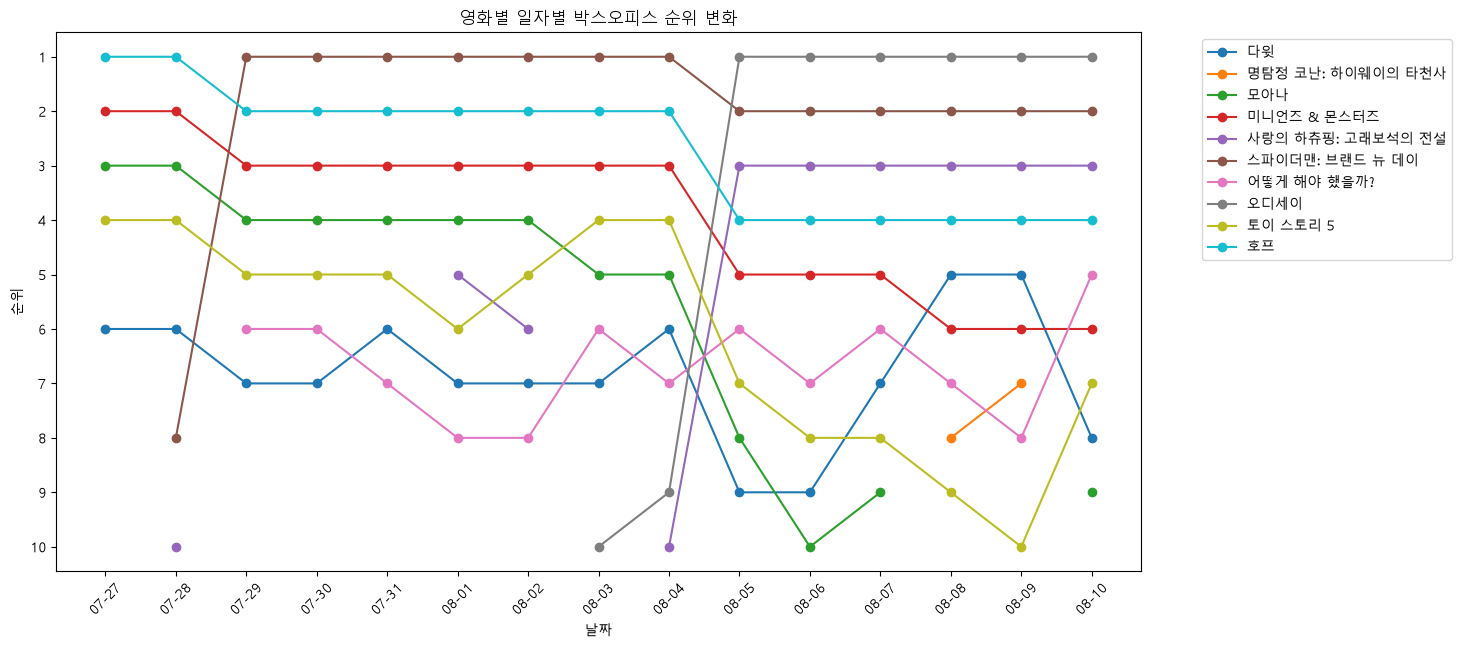

In [178]:
plt.figure(figsize=(14, 7))

for movie in pivot_df.columns:
    plt.plot(
        pivot_df.index,
        pivot_df[movie],
        marker='o',
        label=movie
    )

ax = plt.gca()
ax.invert_yaxis()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.yticks(range(1, 11))

plt.xlabel('날짜')
plt.ylabel('순위')
plt.title('영화별 일자별 박스오피스 순위 변화')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45)

plt.show()

### 영화 순위 변동추이 확인 결과.
- 스파이더맨, 하츄핑, 토이스토리, 모아나, 오디세이, 다윗 영화들이 비교적 급격한 순위 변동이 있었다는 것을 확인.

따라서, 어째서 순위 변동이 급격히 이루어졌는지를 기준으로한 분석 질문을 수립한다.


## 분석질문 수립

- 특정 영화의 개봉 시점에 일부 영화들은 관객 수가 급격히 하락할 것이다.
- 영화의 순위는 일일 관객 수의 영향이 클 것이다.
- 평일에서 주말로 주말에서 평일로 넘어가는 시점에는 모든 영화가 관객수 상향, 하향의 같은 움직임을 보일 것이다.

## 영화별 날짜별 관객 수 증감 추이

In [174]:
pivot_audcnt_df = top_df.pivot(
    index='targetDt',
    columns='영화제목',
    values='당일관객수'
)

pivot_audcnt_df

영화제목,다윗,명탐정 코난: 하이웨이의 타천사,모아나,미니언즈 & 몬스터즈,사랑의 하츄핑: 고래보석의 전설,스파이더맨: 브랜드 뉴 데이,어떻게 해야 했을까?,오디세이,토이 스토리 5,호프
targetDt,,,,,,,,,,
2026-07-27,5037.0,NaN,15049.0,21401.0,NaN,NaN,NaN,NaN,11521.0,103403.0
2026-07-28,5472.0,NaN,15559.0,22069.0,961.0,1254.0,NaN,NaN,12498.0,100154.0
2026-07-29,3669.0,NaN,11102.0,21655.0,NaN,690982.0,3694.0,NaN,9231.0,87892.0
2026-07-30,3836.0,NaN,11882.0,20610.0,NaN,441844.0,3913.0,NaN,9967.0,67623.0
2026-07-31,6272.0,NaN,11630.0,20042.0,NaN,526330.0,4351.0,NaN,10380.0,81496.0
2026-08-01,8795.0,NaN,12729.0,22173.0,10681.0,901580.0,6224.0,NaN,9940.0,136417.0
2026-08-02,9917.0,NaN,12763.0,23030.0,10305.0,826335.0,5434.0,NaN,11554.0,117897.0
2026-08-03,3085.0,NaN,6986.0,12454.0,NaN,401780.0,3147.0,678.0,7454.0,63927.0
2026-08-04,3059.0,NaN,6864.0,12337.0,916.0,348287.0,2991.0,1065.0,7890.0,61234.0


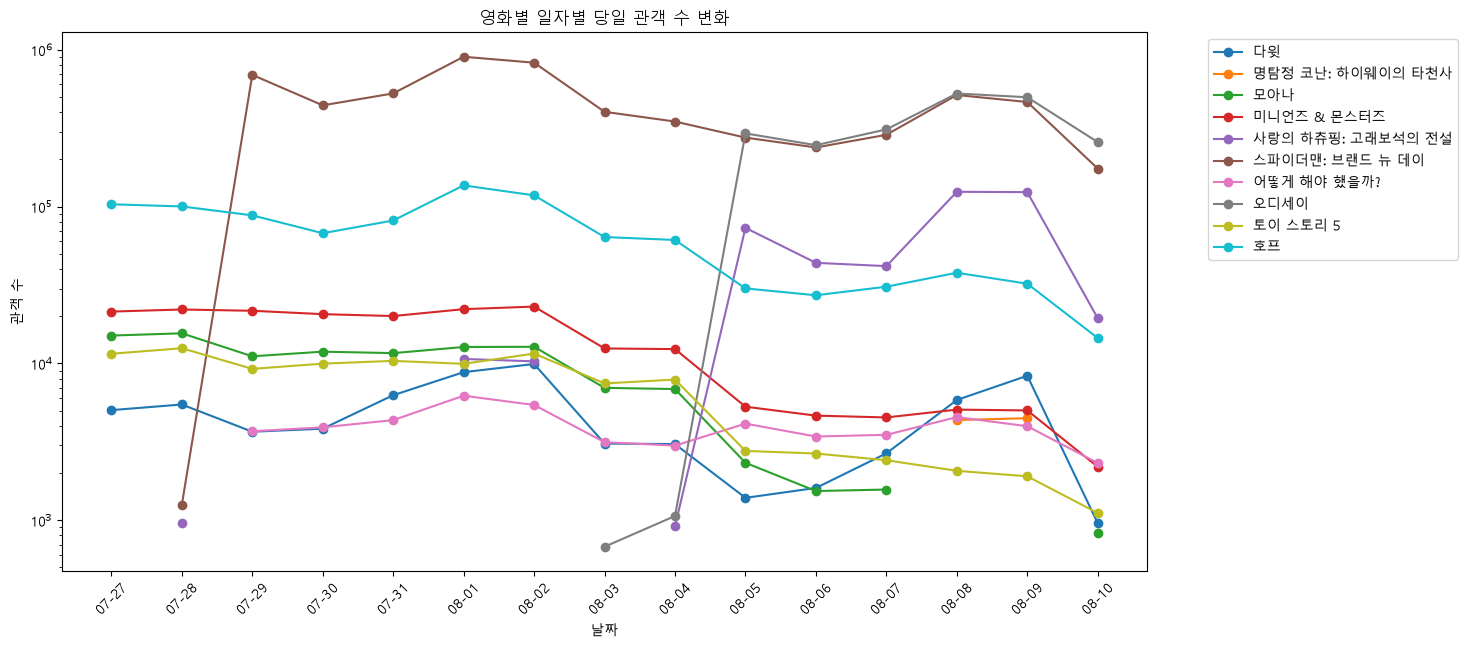

In [179]:
plt.figure(figsize=(14, 7))

for movie in pivot_audcnt_df.columns:
    plt.plot(
        pivot_audcnt_df.index,
        pivot_audcnt_df[movie],
        marker='o',
        label=movie
    )

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.yticks(range(1, 11))

plt.xlabel('날짜')
plt.ylabel('관객 수')
plt.title('영화별 일자별 당일 관객 수 변화')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45)

plt.yscale('log')
plt.show()